run 
```
ti cache clean
python MLUPS_test.py > log_file_name.log
```

In this notebook you can analyse the log file. 

In [50]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [51]:
def real_time_threshold(nLattice,dt):
    return nLattice/dt/1e6

In [52]:
import re

def parse_log(file_path):
    """
    Parse the log file to extract relevant information.

    Args:
        file_path (str): Path to the log file.

    Returns:
        list: A list of dictionaries containing parsed data.
    """
    parsed_data = []

    with open(file_path, 'r') as file:
        content = file.read()

    # Split the log into sections based on the delimiter
    sections = content.split('-----')

    for section in sections:
        if 'LatticeNumber' in section:
            data = {"name": file_path}  # You can customize the name based on the file path or other criteria   

            # Extract architecture
            arch_match = re.search(r'\[Taichi\] Starting on arch=(\w+)', section)
            if arch_match:
                data['arch'] = arch_match.group(1)

            # Extract lattice number
            lattice_match = re.search(r'LatticeNumber\s*:\s*(\d+)', section)
            if lattice_match:
                data['lattice_number'] = int(lattice_match.group(1))

            # Extract average MLUPS
            avg_mlups_match = re.search(r'AvgMLUPS\s*:\s*([\d\.]+)', section)
            if avg_mlups_match:
                data['avg_mlups'] = float(avg_mlups_match.group(1))

            # Extract standard deviation of MLUPS
            std_mlups_match = re.search(r'StdMLUPS\s*:\s*([\d\.]+)', section)
            if std_mlups_match:
                data['std_mlups'] = float(std_mlups_match.group(1))

            # Extract compile time
            compile_time_match = re.search(r'CompileTime\s*:\s*([\d\.]+)', section)
            if compile_time_match:
                data['compile_time'] = float(compile_time_match.group(1))

            # Extract initialization time
            init_time_match = re.search(r'InitTime\s*:\s*([\d\.]+)', section)
            if init_time_match:
                data['init_time'] = float(init_time_match.group(1))

            # Extract execution times
            exe_times_match = re.findall(r'Exe10000Times\s*:\s*\[([\d\.,\s]+)\]', section)
            if exe_times_match:
                data['execution_times'] = [float(x) for x in exe_times_match[0].split(',')]

            parsed_data.append(data)

    return parsed_data

In [53]:
def parse_log_v1(log_file):
    n_lattice_list = []
    macro_MLUPS_list = [] # 总计算量/总时间
    init_time_list = []
    compile_time_list = []
    avg_MLUPS_list = [] # 每次计算量/每次时间 mean
    std_MLUPS_list = [] # 每次计算量/每次时间 std
    with open(log_file, 'r',encoding='utf-8') as f:
        line = f.readline() # 第一行忽略
        line = f.readline()
        while line: 
            line2 = f.readline() # n lattice
            line3 = f.readline() # MLUPS
            line4 = f.readline() # avg time
            line5 = f.readline() # compile time
            line6 = f.readline() # init time
            line7 = f.readline() # v test
            line8 = f.readline() # execution time list
            line9 = f.readline() # -----
            line = f.readline() # EOF or next arch
            nLattice = int(line2)
            n_lattice_list.append(nLattice)
            macro_MLUPS_list.append(float(line3))
            compile_time_list.append(float(line5))
            init_time_list.append(float(line6))
            exec_time_list = [float(t) for t in line8[1:-2].split(',') if t.strip()!='']
            exec_time_array = np.array(exec_time_list)
            MLUPS_array = nLattice*10000 / (exec_time_array * 1e6)
            avg_MLUPS_list.append(np.mean(MLUPS_array))
            std_MLUPS_list.append(np.std(MLUPS_array))
    return n_lattice_list, avg_MLUPS_list, std_MLUPS_list, compile_time_list, init_time_list

In [54]:
def parse_log_v2(log_file):
    n_lattice_list = []
    avg_MLUPS_list = []
    std_MLUPS_list = []
    init_time_list = []
    compile_time_list = []
    with open(log_file, 'r') as f:
        line = f.readline()
        if line.startswith("[Taichi]"):
            pass
        while not line.startswith("[Taichi]"):
            line = f.readline()
        while line: 
            line2 = f.readline() # n lattice
            line3 = f.readline() # avg MLUPS
            line4 = f.readline() # std MLUPS
            line5 = f.readline() # compile time
            line6 = f.readline() # init time
            line8 = f.readline() # execution time list
            line9 = f.readline() # -----
            line = f.readline() # EOF or next arch
            try:
                nLattice = int(line2.split(":")[1].strip())
                n_lattice_list.append(nLattice)
                compile_time_list.append(float(line5.split(":")[1].strip()))
                init_time_list.append(float(line6.split(":")[1].strip()))
                # exec_time_list = [float(t) for t in line8.split(':')[1] if t.strip()!='']
                avg_MLUPS_list.append(float(line3.split(":")[1].strip()))
                std_MLUPS_list.append(float(line4.split(":")[1].strip()))
            except: # invalid ending due to interruption
                pass
    return n_lattice_list, avg_MLUPS_list, std_MLUPS_list, compile_time_list, init_time_list

log/RTX4060_AA_long_all.log 715.5244365546542 77580480
log/RTX4060_AA_short_all.log 809.0673932133616 76238680
log/RTX4060_AA_cube_rough.log 823.174478269268 76765625


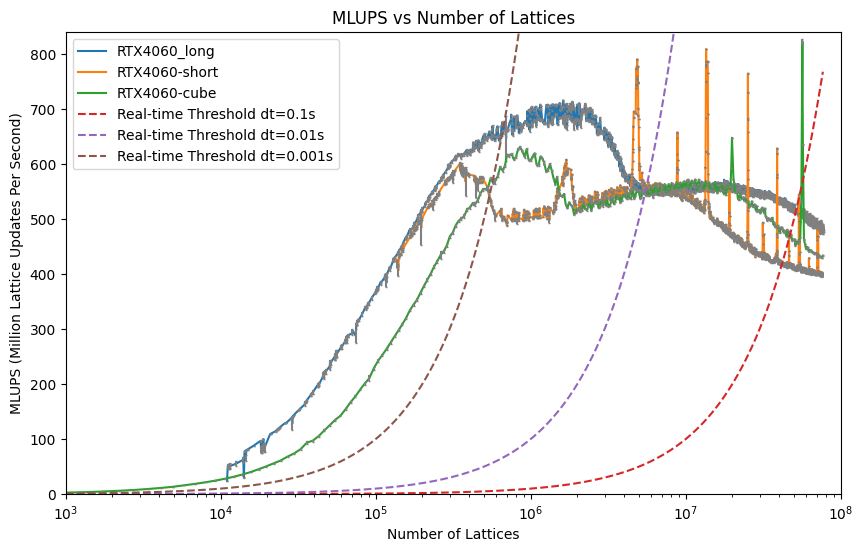

In [73]:
info_list = [
    # ("RTX3090", "log/labComputer_hongxuan_0112_utf8.log"),
    # ("vulkan", "log/YZS_PC_vulkan_MLUPS.log"),
    # ("intel", "log/YZS_laptop_cpu_MLUPS.log"),
    # ("RTX4060-AB", "log/YZS_legion_cuda_all.log"),
    # ("RTX4060-normal", "log/YZS_legion_cuda_AA_all.log"),
    # ("A800-80GB", "log/A800_MLUPS_AA.log"),
    ("RTX4060_long", "log/RTX4060_AA_long_all.log"),
    ("RTX4060-short", "log/RTX4060_AA_short_all.log"),
    ("RTX4060-cube", "log/RTX4060_AA_cube_rough.log"),
    # ("Tesla T4-56GB", "log/Tesla_MLUPS_AA.log"),
    # ("RTX5090-90GB","log/RTX5090_MLUPS_AA.log"),
    # ("Xeon Platinum 8352V","log/32vCPU_Xeon_Platinum8352V_CPU.log"),
    ]
plt.figure(figsize=(10,6))
max_MLUPS = 0
for name,log in info_list:
    data = parse_log(log)
    for i,d in enumerate(data):
        if "lattice_number" not in d or "avg_mlups" not in d or "std_mlups" not in d:
            print(f"Warning: Missing data in log {log} for entry {d} {i}")
    n_lattice_list = [d['lattice_number'] for d in data]
    sort = np.argsort(n_lattice_list)
    n_lattice_list = np.array(n_lattice_list)[sort]
    avg_MLUPS_list = [d['avg_mlups'] for d in data]
    std_MLUPS_list = [d['std_mlups'] for d in data]
    avg_MLUPS_list = np.array(avg_MLUPS_list)[sort]
    std_MLUPS_list = np.array(std_MLUPS_list)[sort]
    plt.plot(n_lattice_list, avg_MLUPS_list, '-', label=name)
    plt.errorbar(n_lattice_list, avg_MLUPS_list, yerr=std_MLUPS_list, fmt='none', ecolor='gray', capsize=1)
    print(data[0]["name"],max(avg_MLUPS_list),max(n_lattice_list))
    max_MLUPS = max(max_MLUPS, max(avg_MLUPS_list))
MLUPS_threshold_list_1 = [real_time_threshold(nLattice,dt=0.1) for nLattice in n_lattice_list]
MLUPS_threshold_list_2 = [real_time_threshold(nLattice,dt=0.01) for nLattice in n_lattice_list]
MLUPS_threshold_list_3 = [real_time_threshold(nLattice,dt=0.001) for nLattice in n_lattice_list]

plt.plot(n_lattice_list, MLUPS_threshold_list_1, '--', label='Real-time Threshold dt=0.1s')
plt.plot(n_lattice_list, MLUPS_threshold_list_2, '--', label='Real-time Threshold dt=0.01s')
plt.plot(n_lattice_list, MLUPS_threshold_list_3, '--', label='Real-time Threshold dt=0.001s')
plt.ylim(0, max_MLUPS*1.02)
plt.xscale('log')
plt.xlim(1e3, 1e8)
plt.xlabel('Number of Lattices')
plt.ylabel(f'MLUPS (Million Lattice Updates Per Second)')
plt.title(f"MLUPS vs Number of Lattices")
plt.legend()
plt.show()

In [56]:


# Example usage
log_file_path = "d:\\sylvain\\etude\\master\\biomass\\lbm\\lbm\\notebook\\log\\YZS_legion_cuda_AA_all.log"
parsed_results = parse_log(log_file_path)
print(parsed_results)

[{'name': 'd:\\sylvain\\etude\\master\\biomass\\lbm\\lbm\\notebook\\log\\YZS_legion_cuda_AA_all.log', 'arch': 'cuda', 'lattice_number': 1320, 'avg_mlups': 6.357302152426053, 'std_mlups': 0.1674315682730931, 'compile_time': 69.26501250267029, 'init_time': 1.2589950561523438, 'execution_times': [2.2112886905670166, 2.0284059047698975, 2.040515899658203, 2.088747024536133, 2.1468849182128906, 2.064845323562622, 2.0431079864501953, 2.030264139175415, 2.0362401008605957, 2.0881199836730957]}, {'name': 'd:\\sylvain\\etude\\master\\biomass\\lbm\\lbm\\notebook\\log\\YZS_legion_cuda_AA_all.log', 'arch': 'cuda', 'lattice_number': 1560, 'avg_mlups': 7.473738812011535, 'std_mlups': 0.274750702736719, 'compile_time': 68.61339020729065, 'init_time': 1.1416754722595215, 'execution_times': [2.2440807819366455, 2.0294148921966553, 2.049374580383301, 2.037757635116577, 2.0493669509887695, 2.0379960536956787, 2.0392956733703613, 2.0453107357025146, 2.131746292114258, 2.2382476329803467]}, {'name': 'd:\\s